In [30]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
df = pd.read_csv('Advertising Budget and Sales.csv',encoding='latin1')
df.head()
df =df.drop('Unnamed: 0',axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales ($)                200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


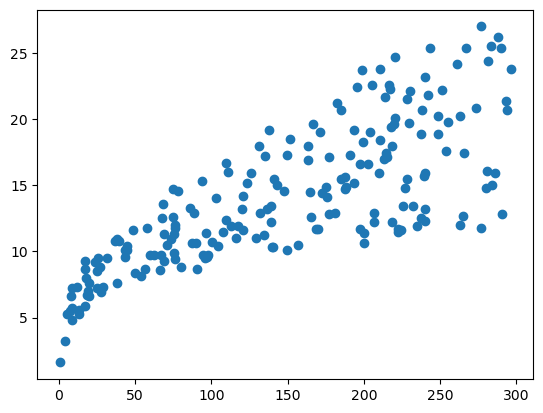

In [32]:
plt.scatter(df['TV Ad Budget ($)'], df['Sales ($)'])

In [33]:
df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [34]:
x = df.drop('Sales ($)', axis=1)
y = df['Sales ($)']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [35]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

In [36]:
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'R^2 Score: {r2}')

Mean Absolute Error: 1.4607567168117606
R^2 Score: 0.899438024100912


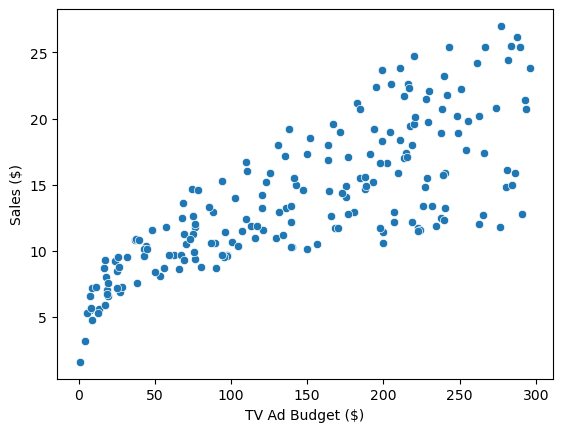

In [42]:
sns.scatterplot(x=df['TV Ad Budget ($)'], y=df['Sales ($)'], marker='o')
plt.savefig('tv_sales_scatter.png', dpi=300)
plt.show()

In [40]:
def prediction(TV_Budget, Radio_Budget, Newspaper_Budget):
    features= np.array([[TV_Budget, Radio_Budget, Newspaper_Budget]])
    sales = lr.predict(features)
    return sales[0]


In [41]:
TV_Budget = 230.1
Radio_Budget = 37.8
Newspaper_Budget = 69.2

sales = prediction(TV_Budget, Radio_Budget, Newspaper_Budget)
print("Predicted Sales:", sales)


Predicted Sales: 20.613971470156294


c:\Users\Sandeep\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [43]:
import pickle
pickle.dump(lr, open('ad_sales_model.pkl', 'wb'))